In [1]:
import numpy as np
import pandas as pd
#scipy stat
from scipy.stats import kurtosis, moment,iqr,binom, binomtest,gmean
from scipy.stats import boxcox
from scipy.stats import skew
import matplotlib.pyplot as plt
import seaborn as sns
###################################################
'''Statemodels'''
###################################################
# # Ordinary Least Squares
import statsmodels.api as sm
from patsy import dmatrices

###################################################
'''sklearn'''
###################################################
# model_selection
from sklearn.model_selection import train_test_split
# preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# pipeline
from sklearn.pipeline import Pipeline
# metrics
from sklearn.metrics import accuracy_score,roc_curve,auc, roc_auc_score                              
                            
#decomposition
from sklearn.compose import ColumnTransformer
import os

In [2]:
# Get tranning Data into Dataframe df
df = pd.read_csv('/kaggle/input/playground-series-s6e2/train.csv')
dfTest = pd.read_csv('/kaggle/input/playground-series-s6e2/test.csv')

df.drop(['id'],axis='columns',inplace=True)
df.columns

Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease'],
      dtype='object')

#### **Introduction**: Predicting Heart Disease with GLMs and Logit Link:

In this project, we address the binary classification task of predicting heart disease using **Generalized Linear Models (GLMs)** with a **logit link** function. GLMs offer a flexible framework for modeling relationships between predictors and a binary outcome, and the logit transformation is particularly well-suited for Bernoulli-distributed targets. By mapping probabilities (bounded between 0 and 1) to the entire real line, the logit link enables linear modeling in a transformed space. This approach allows us to interpret coefficients in terms of log-odds, making it both statistically rigorous and practically interpretable. Compared to more complex models like decision trees or ensemble methods, GLMs provide a transparent baseline that is easy to validate, extend with interaction terms, and communicate to stakeholders.

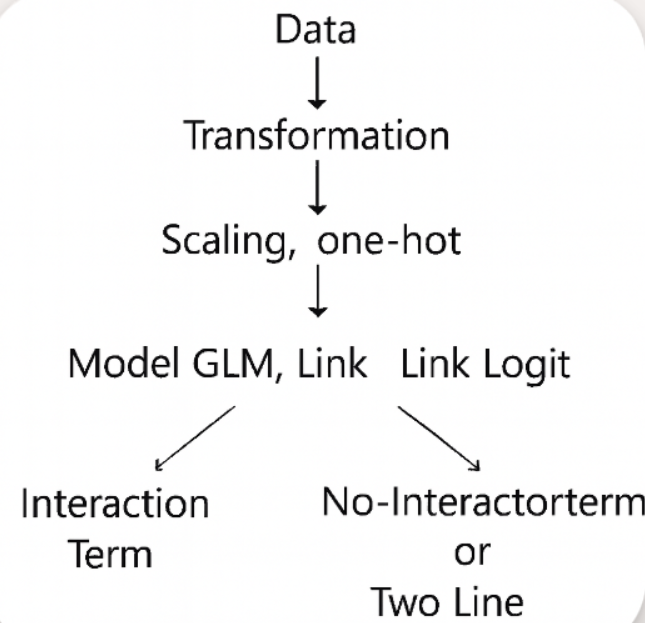

#### Question: What is single line and two line solutions?

To understand this, first we need to understand how the Generalized Linear Model (GLM) works with binary classification, specifically the logistic response function.
The general form of the logistic regression model is:

$y_i\sim \mathrm{Bernoulli}(\pi _i)$

where the $y_i$ are assumed to be independent of one another, each with expected value:

$E(y_i)=\pi _i=\frac{\exp (x_i'\beta )}{1+\exp (x_i'\beta )}$

Here,

$\eta =x'\beta$ 

is the linear predictor, and it is defined by the transformation:

$\eta =\ln \left( \frac{\pi }{1-\pi }\right)$ 

This transformation is often called the logit transformation of the probability $\pi$ . The logit transformation is a very popular approach for modeling Bernoulli or binomial data. It maps $\pi$ , which is bounded between 0 and 1, to the real number line.

Now focus on the linear combination of

$\eta =x'\beta$ 

Suppose we have variables $x_1,x_2,x_3$. Here, $x_1$ and $x_2$ are numerical variables, and $x_3$ is a binary variable. The linear combination equation can then be written as:

$\eta =\beta _0+\beta _1x_1+\beta _2x_2+\beta _3x_3$ -----(1)

Where:
- $\eta$  is the linear predictor,
- $\beta _0$ is the intercept,
- $\beta _1,\beta _2$ are coefficients for numerical variables $x_1,x_2$,
- $\beta _3$ is the coefficient for the binary variable $x_3$.
Equation (1):
$\eta =\beta _0+\beta _1x_1+\beta _2x_2+\beta _3x_3$
Since $x_3$ is a binary variable:
- If $x_3=0$, equation (1) becomes:
  - $\eta =\beta _0+\beta _1x_1+\beta _2x_2$ ----- (2)
- If $x_3=1$, equation (1) becomes:
  - $\eta =\beta _0+\beta _1x_1+\beta _2x_2+\beta _3$
  - $\eta =\beta _0+\beta _1x_1+\beta _2x_2+\beta _3$
  - or equivalently,
  - $\eta =(\beta _0+\beta _3)+\beta _1x_1+\beta _2x_2\quad \mathrm{(3)}$ ---- (3)

So equations (2) and (3) represent two parallel lines: the slope remains the same, but the intercept changes. To avoid this situation,

We introduce interaction terms (sometimes called the single-line solution):

$\eta =\beta _0+\beta _1x_1+\beta _2x_2+\beta _3x_3+\beta _4(x_1x_3)+\beta _5(x_2x_3)$ ---- (4)

Where:
- $\beta _4$ is the coefficient for the interaction between $x_1$ and $x_3$.
- $\beta _5$ is the coefficient for the interaction between $x_2$ and $x_3$.

Equation (4):

$\eta =\beta _0+\beta _1x_1+\beta _2x_2+\beta _3x_3+\beta _4(x_1x_3)+\beta _5(x_2x_3)$

If $x_3=0$, equation (4) simplifies accordingly.

$\eta =\beta _0+\beta _1x_1+\beta _2x_2$    -------- (5)

If $x_3=1$, equation (4) becomes:

$\eta =\beta _0+\beta _1x_1+\beta _2x_2+\beta _3+\beta _4x_1+\beta _5x_2x_3$ ------- (6)

or equivalently,

$\eta =(\beta _0+\beta _3)+(\beta _1+\beta _4)x_1+(\beta _2+\beta _5)x_2$  ------- (6)

Thus, equations (5) and (6) represent different lines with different slopes.

Interactions are “good models” when you suspect that the effect of one predictor depends on another. They make regression more realistic and nuanced, but require careful interpretation.


In [3]:
def plot_glm_roc(glm_result, X_test_const, y_test):
    # Predict probabilities
    y_pred_prob = glm_result.predict(X_test_const)
    y_true = y_test.values if hasattr(y_test, "values") else y_test

    # Compute ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
    roc_auc = roc_auc_score(y_true, y_pred_prob)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], color="red", lw=2, linestyle="--", label="Random guess")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve for GLM Model")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

def evaluate_glm_thresholds(glm_result, X_test_const, y_test, thresholds=None):
    if thresholds is None:
        thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

    # Predict probabilities
    y_pred_prob = glm_result.predict(X_test_const)
    y_true = y_test.values if hasattr(y_test, "values") else y_test
    roc = roc_auc_score(y_true, y_pred_prob)
    roc = round(roc,6)
    # Collect results
    results = []
    for t in thresholds:
        y_pred = (y_pred_prob >= t).astype(int)
        acc = accuracy_score(y_true, y_pred)
        #roc = roc_auc_score(y_true, y_pred_prob)
        results.append({"Threshold": t, "Accuracy": acc, "ROC_AUC": roc})        

    df_results = pd.DataFrame(results)
    best_row = df_results.loc[df_results['Accuracy'].idxmax()]

    return roc

#### Create Interaction Terms:

**Why Multiply Variables i.e.  Age × Cholesterol or BP & Cholesterol?**

- Age × Cholesterol → highlights how time and biology amplify cholesterol’s effect
  - Age and cholesterol individually affect heart disease risk, but their joint effect may be stronger or different than the sum of their separate contributions. Example: High cholesterol in a 25-year-old may not be as risky as the same cholesterol level in a 65-year-old.

- Cholesterol × BP → highlights how two simultaneous lifestyle/health factors compound risk
    - Compounded cardiovascular risk: High cholesterol contributes to plaque buildup in arteries. High blood pressure stresses arterial walls. Together, they accelerate atherosclerosis and increase the likelihood of heart attacks or strokes more than either factor alone.

Multiplying Age * Cholesterol,  BP * Cholestero is a way to let the model learn whether the combination of these two risk factors provides stronger predictive power than treating them separately.


In [4]:
# Apply log transform to skewed features before scaling

# Interaction Features
df['chol_age'] = df['Cholesterol'] * df['Age']
df['bp_chol'] = df['BP'] * df['Cholesterol']

dfTest['chol_age'] = dfTest['Cholesterol'] * dfTest['Age']
dfTest['bp_chol'] = dfTest['BP'] * dfTest['Cholesterol']

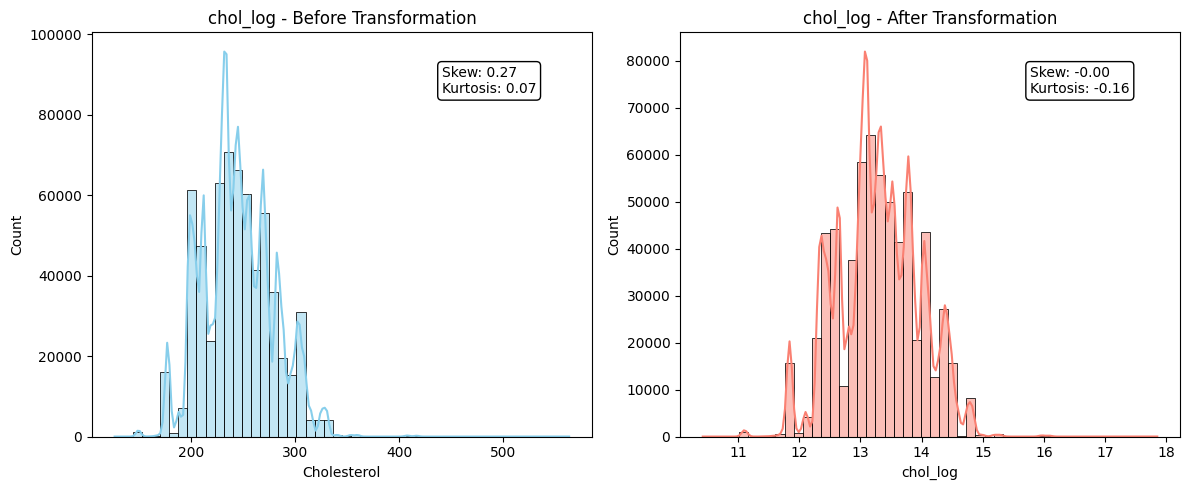

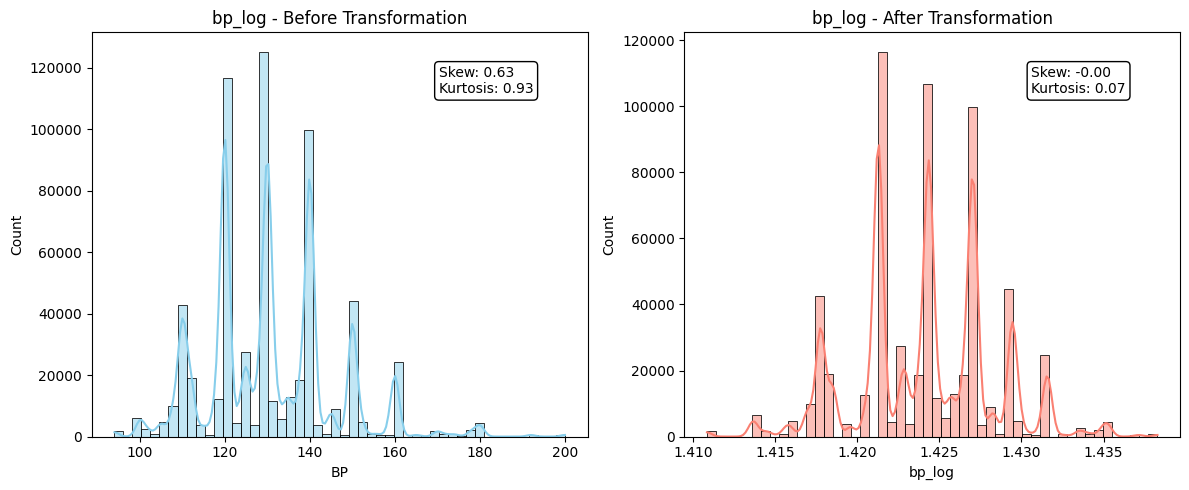

In [5]:
def plot_hist_before_after(var_before, var_after, var_name="Variable"):
    """
    Plot histograms before and after transformation with skewness and kurtosis.

    Parameters
    ----------
    var_before : array-like or pd.Series
        Variable values before transformation.
    var_after : array-like or pd.Series
        Variable values after transformation.
    var_name : str, optional
        Name of the variable being plotted (default: "Variable").
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # --- Before Transformation ---
    sns.histplot(var_before, kde=True, ax=axes[0],bins=50, color="skyblue")
    axes[0].set_title(f"{var_name} - Before Transformation")
    skew_before = skew(var_before)
    kurt_before = kurtosis(var_before)
    axes[0].annotate(f"Skew: {skew_before:.2f}\nKurtosis: {kurt_before:.2f}",
                     xy=(0.7, 0.85), xycoords="axes fraction",
                     fontsize=10, bbox=dict(boxstyle="round", fc="white", ec="black"))

    # --- After Transformation ---
    sns.histplot(var_after, kde=True, ax=axes[1],bins=50, color="salmon")
    axes[1].set_title(f"{var_name} - After Transformation")
    skew_after = skew(var_after)
    kurt_after = kurtosis(var_after)
    axes[1].annotate(f"Skew: {skew_after:.2f}\nKurtosis: {kurt_after:.2f}",
                     xy=(0.7, 0.85), xycoords="axes fraction",
                     fontsize=10, bbox=dict(boxstyle="round", fc="white", ec="black"))

    plt.tight_layout()
    plt.show()

def apply_boxcox(df, col_name, new_col_name):
    """
    Apply Box-Cox transformation on a given column and store result.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    col_name : str
        Column name to transform.
    new_col_name : str
        New column name to store transformed values.

    Returns
    -------
    df : pd.DataFrame
        DataFrame with new transformed column.
    lambda_val : float
        Lambda parameter used in Box-Cox transformation.
    """
    # Ensure strictly positive values
    col_data = df[col_name].copy()
    if (col_data <= 0).any():
        col_data = col_data + abs(col_data.min()) + 1

    transformed, lambda_val = boxcox(col_data)
    df[new_col_name] = transformed

    return df, lambda_val

# BC Transformation for Skewed Features
df, chol_lambda = apply_boxcox(df, 'Cholesterol', 'chol_log')
df, bp_lambda   = apply_boxcox(df, 'BP', 'bp_log')

# BC Transformation for Skewed Features
dfTest, chol_lambda = apply_boxcox(dfTest, 'Cholesterol', 'chol_log')
dfTest, bp_lambda   = apply_boxcox(dfTest, 'BP', 'bp_log')
#print("Box-Cox lambda for Cholesterol:", chol_lambda)
#print("Box-Cox lambda for BP:", bp_lambda)


#df['chol_log'] = np.sqrt(df['Cholesterol'])
#df['bp_log'] = np.log1p(df['BP'])

plot_hist_before_after(var_before = df['Cholesterol'], 
                       var_after = df['chol_log'], 
                       var_name="chol_log")

plot_hist_before_after(var_before = df['BP'], 
                       var_after = df['bp_log'], 
                       var_name="bp_log")

#### logarithmic transformation (or Box-Cox) on the Cholesterol variable:

From Hist plot Before Transformation:

- Skewness ≈ 0.27: Positive skew indicates the tail is longer on the right side.
- Kurtosis ≈ 0.07: Close to zero, suggesting the distribution is not heavily peaked or flat, but still not perfectly normal

After Transformation:

- Skewness ≈ -0.00: Nearly zero, meaning the distribution is balanced around the mean.
- Kurtosis ≈ -0.16: Slightly negative, indicating a distribution a bit flatter than normal, but much closer to Gaussian than before.

The transformation reduces skewness and kurtosis, making cholesterol data more “normal-like,” which improves model stability and predictive performance.

####  logarithmic (or Box-Cox) transformation on the Blood Pressure (BP):

Before Transformation:
- Skewness ≈ 0.63: Positive skew indicates more extreme high BP values than low ones.
- Kurtosis ≈ 0.93: Slightly peaked, meaning the distribution has heavier tails than a normal distribution.

After Transformation:
- Skewness ≈ -0.00: Nearly zero, showing balance around the mean.
- Kurtosis ≈ 0.07: Close to zero, indicating the distribution is now very similar to Gaussian (normal).

The transformation successfully reduced skewness and kurtosis, making BP data more “normal-like,” which improves statistical validity and predictive performance. Residuals and ROC curves look cleaner when predictors are normalized.

In [6]:

y_var = 'Heart Disease'
y = df[y_var].map({'Absence':0, 'Presence':1})

numeric_features = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression','chol_age','bp_chol','chol_log','bp_log']
categorical_features = ['Chest pain type', 'EKG results', 'Slope of ST', 
                        'Number of vessels fluro', 'Thallium']
binary_features = ['Sex', 'FBS over 120', 'Exercise angina']

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features),
        ('bin', 'passthrough', binary_features)
    ])

# Pipeline
pipeline = Pipeline(steps=[('preprocessor', preprocessor)])
df_processed = pipeline.fit_transform(df)
# Get feature names from the ColumnTransformer
feature_names = (
    pipeline.named_steps['preprocessor']
    .get_feature_names_out()
)

df_processed = pd.DataFrame(df_processed, columns=feature_names)
# print(df_processed.columns)
X = df_processed  # features

dfTest_processed = pipeline.fit_transform(dfTest)
# Get feature names from the ColumnTransformer
feature_names = (
    pipeline.named_steps['preprocessor']
    .get_feature_names_out()
)
dfTest_processed = pd.DataFrame(dfTest_processed, columns=feature_names)
print(dfTest_processed.columns)
#print(dfTest['id'])

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,       # 20% test set
    random_state=42,     # reproducibility
    stratify=y           # keeps class distribution balanced
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Index(['num__Age', 'num__BP', 'num__Cholesterol', 'num__Max HR',
       'num__ST depression', 'num__chol_age', 'num__bp_chol', 'num__chol_log',
       'num__bp_log', 'cat__Chest pain type_2', 'cat__Chest pain type_3',
       'cat__Chest pain type_4', 'cat__EKG results_1', 'cat__EKG results_2',
       'cat__Slope of ST_2', 'cat__Slope of ST_3',
       'cat__Number of vessels fluro_1', 'cat__Number of vessels fluro_2',
       'cat__Number of vessels fluro_3', 'cat__Thallium_6', 'cat__Thallium_7',
       'bin__Sex', 'bin__FBS over 120', 'bin__Exercise angina'],
      dtype='object')
Training set shape: (504000, 24)
Test set shape: (126000, 24)


#### GLM full Models with Two line solutions:

In [7]:
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)
model = sm.GLM(y_train, X_train_const, family=sm.families.Binomial(link=sm.families.links.Logit()))
result_two_line_full_models = model.fit()
roc_auc_val = evaluate_glm_thresholds(glm_result   = result_two_line_full_models, 
                        X_test_const = X_test_const, 
                        y_test       = y_test, 
                        thresholds   = None
                        )
print(f'Best ROC AUC score: {roc_auc_val}')
#plot_glm_roc(glm_result = result_two_line_full_models, X_test_const = X_test_const, y_test = y_test)
# Print summary
# print(result_two_line_full_models.summary())

Best ROC AUC score: 0.953733


#### Create Interactions terms

In [8]:
# Replace spaces with underscores in all column names
df_processed.columns = df_processed.columns.str.replace(" ", "_")
y_var = 'Heart Disease'
df_processed['Heart_Disease'] = df[y_var].map({'Absence':0, 'Presence':1})
#print(df_processed.columns)

# Numerical features
numerical_features = [
    'num__Age', 'num__BP', 'num__Cholesterol', 'num__Max_HR',
    'num__ST_depression', 'num__chol_age', 'num__bp_chol',
    'num__chol_log', 'num__bp_log'
]

# Multiclass categorical features (from one-hot encoding)
multiclass_features = [
    'cat__Chest_pain_type_2', 'cat__Chest_pain_type_3', 'cat__Chest_pain_type_4',
    'cat__EKG_results_1', 'cat__EKG_results_2',
    'cat__Slope_of_ST_2', 'cat__Slope_of_ST_3',
    'cat__Number_of_vessels_fluro_1', 'cat__Number_of_vessels_fluro_2', 'cat__Number_of_vessels_fluro_3',
    'cat__Thallium_6', 'cat__Thallium_7'
]

# Binary features
binary_features = [
    'bin__Sex', 'bin__FBS_over_120', 'bin__Exercise_angina'
]
# Generate interaction feature names
interaction_features = [
    f"{num}*{cat}" for num in numerical_features for cat in multiclass_features
]
# Combine all features into formula string
all_features = numerical_features + multiclass_features + binary_features + interaction_features
formula = "Heart_Disease ~ " + " + ".join(all_features)

# Write formula into a text file
with open("formula.txt", "w") as f:
    f.write(formula)
#print(df_processed.columns)
#print("Formula:\n", formula[:200], "...")  # preview first 200 chars
# Create design matrices
y, X = dmatrices(formula, df_processed, return_type='dataframe')

print("X shape:", X.shape)
print("y shape:", y.shape)

X_train_Single_sol, X_test_Single_sol, y_train_Single_sol, y_test_Single_sol = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'shape of X_train_Single_sol {X_train_Single_sol.shape}')
print(f'shape of X_test_Single_sol {X_test_Single_sol.shape}')
print(f'shape of y_train_Single_sol {y_train_Single_sol.shape}')
print(f'shape of y_test_Single_sol {y_test_Single_sol.shape}')

X shape: (630000, 133)
y shape: (630000, 1)
shape of X_train_Single_sol (504000, 133)
shape of X_test_Single_sol (126000, 133)
shape of y_train_Single_sol (504000, 1)
shape of y_test_Single_sol (126000, 1)


#### GLM Models with Single Line full models solutions

In [9]:
model = sm.GLM(y_train_Single_sol, X_train_Single_sol, family=sm.families.Binomial(link=sm.families.links.Logit()))
result_single_line_fm = model.fit()
roc_auc_val = evaluate_glm_thresholds(glm_result   = result_single_line_fm, 
                        X_test_const = X_test_Single_sol, 
                        y_test       = y_test_Single_sol, 
                        thresholds   = None
                        )
print(f'Best ROC AUC score: {roc_auc_val}')
#plot_glm_roc(glm_result = result_single_line_fm, X_test_const = X_test_Single_sol, y_test = y_test_Single_sol)
# Print summary
# print(result_single_line_fm.summary())

Best ROC AUC score: 0.953771


#### Remove variable where null hypothesis true

In [10]:
# Get p-values
p_values = result_single_line_fm.pvalues

# Filter significant variables
significant_vars = p_values[p_values <= 0.05].index.tolist()

# Subset your training DataFrame
X_train_Single_line_sol_rm_01 = X_train_Single_sol[significant_vars]
X_test_Single_line_sol_rm_01 = X_test_Single_sol[significant_vars]
y_train_Single_sol_rm_01 = y_train_Single_sol
y_test_Single_sol_rm_01 = y_test_Single_sol

print(f'shape of X_train_Single_line_sol_rm_01 {X_train_Single_line_sol_rm_01.shape}')
print(f'shape of X_test_Single_line_sol_rm_01 {X_test_Single_line_sol_rm_01.shape}')
print(f'shape of y_train_Single_sol_rm_01 {y_train_Single_sol_rm_01.shape}')
print(f'shape of y_test_Single_sol_rm_01 {y_test_Single_sol_rm_01.shape}')

shape of X_train_Single_line_sol_rm_01 (504000, 36)
shape of X_test_Single_line_sol_rm_01 (126000, 36)
shape of y_train_Single_sol_rm_01 (504000, 1)
shape of y_test_Single_sol_rm_01 (126000, 1)


In [11]:
model = sm.GLM(y_train_Single_sol_rm_01, X_train_Single_line_sol_rm_01, 
            family=sm.families.Binomial(link=sm.families.links.Logit()))
result_single_line_rm_01 = model.fit()
roc_auc_val = evaluate_glm_thresholds(glm_result   = result_single_line_rm_01, 
                        X_test_const = X_test_Single_line_sol_rm_01, 
                        y_test       = y_test_Single_sol_rm_01, 
                        thresholds   = None
                        )
print(f'Best ROC AUC score: {roc_auc_val}')
#plot_glm_roc(glm_result = result_single_line_rm_01, X_test_const = X_test_Single_line_sol_rm_01, y_test = y_test_Single_sol_rm_01)
# Print summary
# print(result_single_line_rm_01.summary())

Best ROC AUC score: 0.953733


In [12]:
# Get p-values
p_values = result_single_line_rm_01.pvalues

# Filter significant variables
significant_vars = p_values[p_values <= 0.05].index.tolist()

# Subset your training DataFrame
X_train_Single_line_sol_rm_02 = X_train_Single_line_sol_rm_01[significant_vars]
X_test_Single_line_sol_rm_02 = X_test_Single_line_sol_rm_01[significant_vars]
y_train_Single_sol_rm_02 = y_train_Single_sol_rm_01
y_test_Single_sol_rm_02 = y_test_Single_sol_rm_01

print(f'shape of X_train_Single_line_sol_rm_01 {X_train_Single_line_sol_rm_02.shape}')
print(f'shape of X_test_Single_line_sol_rm_01 {X_test_Single_line_sol_rm_02.shape}')
print(f'shape of y_train_Single_sol_rm_01 {y_train_Single_sol_rm_02.shape}')
print(f'shape of y_test_Single_sol_rm_01 {y_test_Single_sol_rm_02.shape}')

shape of X_train_Single_line_sol_rm_01 (504000, 31)
shape of X_test_Single_line_sol_rm_01 (126000, 31)
shape of y_train_Single_sol_rm_01 (504000, 1)
shape of y_test_Single_sol_rm_01 (126000, 1)


#### Final Models

In [13]:
model = sm.GLM(y_train_Single_sol_rm_02, X_train_Single_line_sol_rm_02, 
            family=sm.families.Binomial(link=sm.families.links.Logit()))
result_single_line_rm_02 = model.fit()
roc_auc_val = evaluate_glm_thresholds(glm_result   = result_single_line_rm_02, 
                        X_test_const = X_test_Single_line_sol_rm_02, 
                        y_test       = y_test_Single_sol_rm_02, 
                        thresholds   = None
                        )
print(f'Best ROC AUC score: {roc_auc_val}')
#plot_glm_roc(glm_result = result_single_line_rm_02, X_test_const = X_test_Single_line_sol_rm_02, y_test = y_test_Single_sol_rm_02)

# print(result_single_line_rm_02.summary())

Best ROC AUC score: 0.953734


In [14]:
#test_id_col = dfTest.id
X_test_processed = sm.add_constant(dfTest_processed)
processed_test_pred = result_two_line_full_models.predict(X_test_processed)
submission = pd.DataFrame({
    'id': dfTest.id,
    'Heart Disease': processed_test_pred})
submission.to_csv('submission.csv', index=False)